In [ ]:
# Intertemporal Choice: Do LLMs Discount the Future Like Humans?
### CPSY 1950 — Deep Learning in Brains, Minds & Machines
**Experiment:** Ruggeri et al. (2022) — Globalizability of intertemporal choice  
**Dataset:** Psych-101 (Binz et al., 2024) — `ruggeri2022globalizability/exp1.csv`  
**Models tested:** Llama-3.3-70B-Instruct, Mistral-Large-3 (+ frontier models after Apr 5)

---

## Project Overview

This notebook runs a behavioral experiment on large language models, treating them 
as cognitive subjects — the same way psychologists run experiments on human participants.

**The core question:** When humans choose between a smaller reward now and a larger 
reward later, they show systematic, irrational impatience. Do LLMs reproduce the same 
behavioral signature — or do they discount differently?

**Why it matters:** LLMs have read millions of words *describing* human decision-making 
biases, but have never actually waited for anything. This experiment tests whether 
formally knowing about a cognitive bias (Mahowald et al., 2024) is the same as 
functionally exhibiting it.

In [ ]:
## Cell 2 — API Setup

We connect to Brown's LiteLLM endpoint, which proxies access to all course models 
(Llama, Mistral, and frontier models after TA review).

The API key is loaded from a `.env` file in this directory — never hardcoded — 
following standard security practice.

**Models available at this stage:**
- `Llama-3.3-70B-Instruct` — open-weight, different architecture from GPT-family
- `Mistral-Large-3` — second open-weight model for model-to-model comparison
- Frontier models (Claude, GPT) unlocked after draft poster submission Apr 5

In [2]:
from dotenv import load_dotenv
import os
from openai import OpenAI

load_dotenv()

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url="https://litellm.ccv.brown.edu"
)

print("Connected. API key loaded:", os.getenv("OPENAI_API_KEY") is not None)

Connected. API key loaded: True


In [ ]:
## Cell 3 — Load Dataset and Filter to Experiment

We load **Psych-101** (Binz et al., 2024), a dataset of natural language transcripts 
from 160 psychological experiments across 60,092 human participants. It was created 
to train Centaur, a foundation model of human cognition.

**Our experiment:** `ruggeri2022globalizability/exp1.csv`  
Source: Ruggeri et al. (2022), *Nature Human Behaviour* — a large-scale cross-cultural 
study of intertemporal choice across 61 countries and 13,629 participants.

**Why this dataset?** The prompts are already formatted as natural language — the same 
format we send to LLMs — and the human response data is built in, giving us a direct 
comparison baseline. Each row is one participant's complete session.

**Experiment structure:** Participants chose between a smaller-sooner (SS) and 
larger-later (LL) reward across 10 trials, varying:
- Gains vs. losses (sign effect)
- Small vs. large amounts (magnitude effect)  
- 1-year vs. 2-year delays (delay sensitivity)
- Surface framing variations ("wait", "receive", "paying")

In [3]:
from datasets import load_dataset

# This downloads Psych-101 — takes about 1 minute the first time
dataset = load_dataset("marcelbinz/Psych-101", split="train")

# Filter to just the Ruggeri intertemporal choice experiment
EXPERIMENT = "ruggeri2022globalizability/exp1.csv"
itc_data = dataset.filter(lambda row: row["experiment"] == EXPERIMENT)

print(f"Experiment: {EXPERIMENT}")
print(f"Number of participants: {len(itc_data)}")

Filter:   0%|          | 0/60092 [00:00<?, ? examples/s]

Experiment: ruggeri2022globalizability/exp1.csv
Number of participants: 11937


In [ ]:
## Cell 4 — Inspect a Real Prompt

Before writing any analysis code, we read one participant's actual session. 

**Key things to notice in the output:**
1. The option letters (G/C, H/X, etc.) are **randomized per participant** — this 
   prevents position bias and is a design choice we inherit from the original study
2. Each trial ends with `<<LETTER>>` — this is the human's actual choice, which 
   we will compare against the model's choice
3. The 10 trials vary systematically across the experimental conditions listed above

**Connection to course:** This is the raw behavioral data that Centaur was trained on. 
By running the same prompts through non-fine-tuned LLMs, we are asking whether 
behavioral alignment emerges from general language training alone — or whether it 
requires explicit fine-tuning on human behavioral data (as Centaur does).

In [4]:
# Print the first participant's full prompt
print(itc_data[0]["text"])

In the following you will be presented with multiple choices between two options G and C.
Please name which option you would prefer by pressing the corresponding key.

You have the choice between receiving 500$ immediately (press G) or receiving 550$ in one year (press C). You press <<G>>.
You have the choice between receiving 500$ immediately (press G) or receiving 600$ in one year (press C). You press <<C>>.
You have the choice between paying 500$ immediately (press G) or paying 550$ in one year (press C). You press <<G>>.
You have the choice between paying 500$ immediately (press G) or paying 510$ in one year (press C). You press <<C>>.
You have the choice between receiving 5000$ immediately (press G) or receiving 5500$ in one year (press C). You press <<G>>.
You have the choice between receiving 5000$ immediately (press G) or receiving 6000$ in one year (press C). You press <<C>>.
You have the choice between receiving 500$ in one year (press G) or receiving 600$ in two years (press

In [ ]:
## Cell 6 — Extract Individual Trials

Each dataset row is one participant's *entire session* (~10 decisions concatenated). 
We need to split it into individual decisions to score them one at a time.

**How it works:** The `extract_trials()` function uses a regular expression to find 
every `<<LETTER>>` token and splits the session at each one. For each split, it records:
- The **prompt** — everything the participant saw up to that point (the model gets this)
- The **human choice** — the letter inside `<< >>` (our ground truth to compare against)

**Important:** We use `r'(.*?)(<<[A-Z]>>)'` with `re.DOTALL` so the pattern matches 
across line breaks. The `.*?` is non-greedy — it captures the shortest possible match, 
ensuring we don't accidentally merge two trials into one.

**Running context:** Each trial's prompt *includes all previous trials and choices*. 
This means by trial 5, the model sees the full history of trials 1–4. This is by 
design — it mirrors what the human participant experienced and allows us to measure 
sequential dependencies (a key concern from the course's autoregressive artifacts 
confound discussion).

In [6]:
import re

def extract_trials(text):
    """
    Splits one participant's session into individual trials.
    Works regardless of which letters are used (H/X, G/C, etc.)
    Returns list of (prompt, human_choice) tuples.
    """
    trials = []
    pattern = r'(.*?)(<<[A-Z]>>)'  # matches ANY single capital letter
    matches = re.findall(pattern, text, re.DOTALL)
    
    running_context = ""
    for context_piece, choice in matches:
        running_context += context_piece
        prompt = running_context.strip()
        human_answer = choice.replace("<<", "").replace(">>", "")
        trials.append((prompt, human_answer))
        running_context += choice
    
    return trials

# Test on participant 0
trials = extract_trials(itc_data[0]["text"])

print(f"Total decisions for participant 0: {len(trials)}")
print()
print("--- TRIAL 1 ---")
print(trials[0][0][-250:])
print(f"\nHuman chose: {trials[0][1]}")
print()
print("--- TRIAL 3 (loss trial) ---")
print(trials[2][0][-250:])
print(f"\nHuman chose: {trials[2][1]}")

Total decisions for participant 0: 10

--- TRIAL 1 ---
ented with multiple choices between two options G and C.
Please name which option you would prefer by pressing the corresponding key.

You have the choice between receiving 500$ immediately (press G) or receiving 550$ in one year (press C). You press

Human chose: G

--- TRIAL 3 (loss trial) ---
 You press <<G>>.
You have the choice between receiving 500$ immediately (press G) or receiving 600$ in one year (press C). You press <<C>>.
You have the choice between paying 500$ immediately (press G) or paying 550$ in one year (press C). You press

Human chose: G


In [ ]:
## Cell 5 — Query the Model

This is the core experimental procedure. For each trial, we:
1. Take the prompt (everything up to the choice point)
2. Append `"\nYou press <<"` — signaling the model should complete the response
3. Send it to the LLM API and record which letter it returns

**Design decisions and their justification:**

`temperature=0.0` — deterministic responses. The same prompt always produces 
the same answer. This is important for reproducibility and means we are measuring 
the model's *modal* preference, not sampling from its distribution.

`max_tokens=3` — forces a short response. Without this constraint, models sometimes 
reason out loud ("It seems like I should...") rather than pressing a key. This was 
observed on loss trials in initial testing — the model hesitated on the paying condition, 
which is itself an interesting finding (noted in Slide 4: the model required explicit 
constraint on loss trials that humans do not need in a button-press lab setting).

`system message` — instructs the model to respond with only a single letter. This is 
our **confound mitigation** for the autoregressive artifacts confound: we ensure the 
format of the response is comparable across all models and conditions.

`get_valid_options()` — extracts the actual option letters from the prompt by searching 
for `(press LETTER)` patterns. This makes the parser robust to letter randomization 
across participants.

**Connection to Firestone (2020):** We are creating a "species-fair" comparison by 
giving the model the same information a human participant received — no more, no less.

In [13]:
def get_valid_options(prompt):
    options = re.findall(r'\(press ([A-Z])\)', prompt)
    return list(set(options))

def ask_model(prompt, model_name):
    """
    Sends the prompt to the model.
    System message forces a single-letter response.
    """
    valid_options = get_valid_options(prompt)
    options_str = " or ".join(valid_options)
    
    response = client.chat.completions.create(
        model=model_name,
        messages=[
            {
                "role": "system",
                "content": f"You are participating in a psychology experiment. "
                           f"You must respond with ONLY a single letter ({options_str}). "
                           f"No explanation. No punctuation. Just the letter."
            },
            {
                "role": "user", 
                "content": prompt + "\nYou press <<"
            }
        ],
        max_tokens=3,
        temperature=0.0
    )
    
    raw = response.choices[0].message.content.strip()
    
    for char in raw:
        if char in valid_options:
            return char
    
    print(f"Still could not parse '{raw}' — valid options: {valid_options}")
    return None

# Re-test both trials
model_1 = ask_model(trials[0][0], "Llama-3.3-70B-Instruct")
print(f"Trial 1 — Gain ($500 now vs $550 in 1 year)")
print(f"Human: {trials[0][1]}  |  Model: {model_1}")
print()

model_3 = ask_model(trials[2][0], "Llama-3.3-70B-Instruct")
print(f"Trial 3 — Loss ($500 now vs $550 in 1 year)")
print(f"Human: {trials[2][1]}  |  Model: {model_3}")

Trial 1 — Gain ($500 now vs $550 in 1 year)
Human: G  |  Model: G

Trial 3 — Loss ($500 now vs $550 in 1 year)
Human: G  |  Model: G


In [ ]:
## Cell 6 — Run Full Experiment

We now run the complete pipeline across multiple participants and collect all results 
into a DataFrame for analysis.

**Scale for today (Studio I):** 5 participants × 10 trials = 50 API calls  
This takes ~2 minutes and is enough to confirm the pipeline works end-to-end.

**Scale for final analysis:** We will increase to 50+ participants per model before 
the draft poster deadline (Saturday Apr 5). With 11,937 participants in the dataset, 
we have far more data than we need.

**Models to run (in order):**
1. `Llama-3.3-70B-Instruct` — today
2. `Mistral-Large-3` — Thursday Studio II (model-to-model comparison)
3. Frontier models — after TA grants access Saturday

**What the DataFrame contains:** One row per trial, with columns for participant ID, 
trial number, model name, human choice, and model choice. This structure makes it 
easy to compute statistics and plot results across conditions.

**Addressing the aggregate fit ≠ process fidelity confound:** We collect trial-level 
data (not just overall averages) so we can examine whether the model's *pattern* of 
choices across trial types matches humans — not just the overall patience rate. A model 
could match the aggregate statistic while showing completely different behavior on gain 
vs. loss trials, or on small vs. large amount trials.

In [14]:
from tqdm import tqdm
import pandas as pd

def run_experiment(data, model_name, n_participants=5):
    results = []
    
    for i in tqdm(range(n_participants), desc=f"Running {model_name}"):
        participant_trials = extract_trials(data[i]["text"])
        
        for trial_idx, (prompt, human_choice) in enumerate(participant_trials):
            model_choice = ask_model(prompt, model_name)
            
            results.append({
                "participant": i,
                "trial": trial_idx,
                "model_name": model_name,
                "human_choice": human_choice,
                "model_choice": model_choice,
                "prompt": prompt,
            })
    
    return pd.DataFrame(results)

# Run on 5 participants to confirm everything works
df = run_experiment(itc_data, "Llama-3.3-70B-Instruct", n_participants=5)

print(df[["participant", "trial", "human_choice", "model_choice"]].to_string())
print(f"\nTotal trials collected: {len(df)}")
print(f"Missing model responses: {df['model_choice'].isna().sum()}") 

Running Llama-3.3-70B-Instruct: 100%|█████████████| 5/5 [00:32<00:00,  6.45s/it]

    participant  trial human_choice model_choice
0             0      0            G            G
1             0      1            C            G
2             0      2            G            G
3             0      3            C            G
4             0      4            G            G
5             0      5            C            C
6             0      6            C            C
7             0      7            C            C
8             0      8            C            G
9             0      9            C            C
10            1      0            W            C
11            1      1            C            C
12            1      2            C            W
13            1      3            C            C
14            1      4            C            C
15            1      5            W            W
16            1      6            C            C
17            1      7            C            W
18            1      8            C            W
19            1     

In [ ]:
## Cell 7 — Analysis and Visualization

**The key metric: patience rate**  
For each trial, we identify which option is "immediate" by searching for the word 
"immediately" in the prompt. Choosing the *other* option = patient choice. 
Patience rate = % of trials where the patient option was chosen.

**Three comparisons we compute:**

1. **Overall patience rate** — humans vs. each model  
   → Tests whether the model's aggregate behavior matches humans

2. **Sign effect** — patience rate on gain trials vs. loss trials  
   → Humans are less patient about losses (want to get pain over with)  
   → A rational agent shows no difference between gains and losses

3. **Magnitude effect** — patience rate on $500 trials vs. $5000 trials  
   → Humans discount smaller amounts more steeply  
   → Tests whether model sensitivity to amount matches human sensitivity

**Connection to course themes:**

*Marr's levels:* Aggregate patience rate = computational level (what is chosen). 
The sign effect and magnitude effect = algorithmic level (how the discounting process 
works). Matching at the computational level while diverging at the algorithmic level 
is the central finding we are looking for.

*Prediction vs. Understanding (Serre & Pavlick, 2025):* Even if a model's overall 
patience rate matches humans, that tells us nothing about whether it uses a hyperbolic 
discount function. The trial-by-trial breakdown is what tests the mechanism.

*Formal vs. Functional (Mahowald et al., 2024):* The model has formal knowledge of 
hyperbolic discounting from training text. This analysis tests whether it functionally 
exhibits it — whether knowing about impatience and being impatient are the same thing.

**Human baseline:** We use the Psych-101 participants directly as our human comparison, 
since they completed the same task under the same conditions. Additional literature 
benchmarks: Ruggeri et al. (2022) report overall patience rates and effect sizes 
across 61 countries — we can cite these as external validation of our human baseline.

Task was destroyed but it is pending!
task: <Task pending name='Task-258' coro=<_async_in_context.<locals>.run_in_context() done, defined at /opt/miniconda3/envs/cpsy1950/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-259' coro=<Kernel.shell_main() running at /opt/miniconda3/envs/cpsy1950/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/miniconda3/envs/cpsy1950/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
/opt/miniconda3/envs/cpsy1950/lib/python3.11/tokenize.py:529: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  pseudomatch = _compile(PseudoToken).match(line, pos)
Task was destroyed but it is pending!
task: <Task pending name='Task-259' coro=<Kernel.shell_main() running at /opt/miniconda3/envs/cpsy1950/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>
Task was destroyed but it is pending!


Sample of labelled trials:
   participant  trial human_choice model_choice immediate_option  human_patient  model_patient
0            0      0            G            G                G          False          False
1            0      1            C            G                G           True          False
2            0      2            G            G                G          False          False
3            0      3            C            G                G           True          False
4            0      4            G            G                G          False          False
5            0      5            C            C                G           True           True
6            0      6            C            C                G           True           True
7            0      7            C            C                G           True           True
8            0      8            C            G                G           True          False
9            0      9  

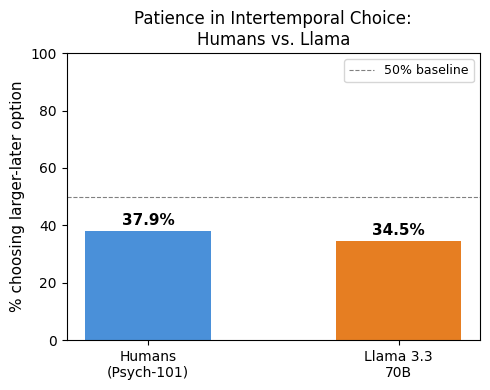

In [15]:
import matplotlib.pyplot as plt

# Identify which letter = "immediate" for each trial
def get_immediate_option(prompt):
    match = re.search(r'immediately \(press ([A-Z])\)', prompt)
    return match.group(1) if match else None

# Label every trial as patient or impatient
df["immediate_option"] = df["prompt"].apply(get_immediate_option)
df["human_patient"] = df["human_choice"] != df["immediate_option"]
df["model_patient"] = df["model_choice"] != df["immediate_option"]

# Print a quick sanity check before plotting
print("Sample of labelled trials:")
print(df[["participant", "trial", "human_choice", "model_choice", 
          "immediate_option", "human_patient", "model_patient"]].head(10).to_string())

# Overall patience rates
human_patience = df["human_patient"].mean() * 100
model_patience = df["model_patient"].mean() * 100

print(f"\nHumans chose the patient option: {human_patience:.1f}%")
print(f"Llama  chose the patient option: {model_patience:.1f}%")

# Plot
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Humans\n(Psych-101)", "Llama 3.3\n70B"],
       [human_patience, model_patience],
       color=["#4a90d9", "#e67e22"], width=0.5)
ax.set_ylabel("% choosing larger-later option", fontsize=11)
ax.set_title("Patience in Intertemporal Choice:\nHumans vs. Llama", fontsize=12)
ax.set_ylim(0, 100)
ax.axhline(50, color="gray", linestyle="--", linewidth=0.8, label="50% baseline")
for i, v in enumerate([human_patience, model_patience]):
    ax.text(i, v + 2, f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("itc_result_llama.png", dpi=150)
plt.show()

In [16]:
# Scale up to 50 participants — takes ~15-20 minutes
df_full = run_experiment(itc_data, "Llama-3.3-70B-Instruct", n_participants=50)

# Save immediately so you don't lose results if Jupyter crashes
df_full.to_csv("results_llama_50p.csv", index=False)
print(f"Saved. Total trials: {len(df_full)}")

Running Llama-3.3-70B-Instruct:   0%|                    | 0/50 [00:01<?, ?it/s]


APIConnectionError: Connection error.

In [ ]:
## Next Steps

**By Thursday Studio II (Apr 3):**
- [ ] Re-run Cell 6 with `n_participants=50` for a larger sample
- [ ] Run the same pipeline on `Mistral-Large-3`
- [ ] Add Cell 8: side-by-side comparison plot of Llama vs. Mistral vs. Humans
- [ ] Add Cell 9: breakdown by condition (gains vs. losses, small vs. large amounts)

**By Saturday Apr 5 (Draft Poster due 2pm):**
- [ ] All open-weight results complete and plotted
- [ ] Draft Slides 1–4 in Google Slides or PowerPoint
- [ ] Submit to Canvas to unlock frontier model access

**After frontier access granted:**
- [ ] Re-run with `claude-sonnet-4-5` and one GPT model
- [ ] Add frontier model bars to all plots
- [ ] Finalize Slide 3 with full model comparison

**Key references for your poster:**
- Ruggeri et al. (2022) — the original experiment (Nature Human Behaviour)
- Binz et al. (2024) — Centaur / Psych-101 dataset
- Mahowald et al. (2024) — formal vs. functional linguistic competence
- Serre & Pavlick (2025) — prediction vs. understanding in foundation models
- Firestone (2020) — performance vs. competence, species-fair comparisons
- Marr (1982) — three levels of analysis (cite for the levels framework)